<a href="https://colab.research.google.com/github/Onyimatics/loan_approval_prediction/blob/master/Loan_Status_Application_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<H1>IMPORTING DEPENDENCIES </H2>

In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

<H1> DATA LOADER </H2>

In [ ]:
# DataLoader class: Class to load data and provide initial insights.
class DataLoader:

    # Class constructor
    # It allows to set up the initial state of an object by assigning values to its attributes
    def __init__(self, file_path):
        self.file_path = file_path

    # Loads data from a file path.
    def load_data(self):
        data = pd.read_csv(self.file_path)
        # Need to drop this Loan_ID column because I want to plot some distributions of the data before preprocessing the data.
        # This will only happen if Loan_ID exist as a column in the dataset.
        if 'Loan_ID' in data.columns:
            data = data.drop(['Loan_ID'], axis=1)
            print("Dropped column 'Loan_ID'")
        print(f"Data loaded with shape: {data.shape}")
        return data

<H1> DATA PREPROCESSING </H2>

In [ ]:
# DataPreprocessor Class: Class to preprocess loan data
class DataPreprocessor:

    def __init__(self, df):
        self.df = df

    # Handles missing values in the dataset.
    def handle_missing_values(self):
      # Replace '3+' with 4 in Dependents, and fill missing values in Dependents with mode
      self.df['Dependents'] = self.df['Dependents'].replace('3+', 4).fillna(self.df['Dependents'].mode()[0]).astype(int)

      # Fill missing values in categorical columns with mode
      categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
      for col in categorical_cols:
          self.df[col] = self.df[col].fillna(self.df[col].mode()[0])

      # Fill missing values in numerical columns with mean
      numerical_cols = ['LoanAmount', 'ApplicantIncome', 'CoapplicantIncome']
      for col in numerical_cols:
          self.df[col] = self.df[col].fillna(self.df[col].mean())

      # Specific handling for Loan_Amount_Term and Credit_History
      self.df['Loan_Amount_Term'] = self.df['Loan_Amount_Term'].fillna(self.df['Loan_Amount_Term'].mode()[0])
      self.df['Credit_History'] = self.df['Credit_History'].fillna(self.df['Credit_History'].mode()[0])

    def encode_categorical_variables(self):
        """Encodes categorical variables to ensure all columns are numeric."""
        categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
        for col in categorical_cols:
            # Convert each categorical column to numerical using Label Encoding
            self.df[col] = LabelEncoder().fit_transform(self.df[col])

    # Scales numerical features using StandardScaler.
    def scale_features(self):
        scaler = StandardScaler()
        numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
        self.df[numerical_cols] = scaler.fit_transform(self.df[numerical_cols])

    # Removes duplicate rows if found.
    def check_and_remove_duplicates(self):
        duplicates = self.df.duplicated().sum()
        if duplicates > 0:
            print(f"Found {duplicates} duplicate rows. Removing duplicates...")
            self.df = self.df.drop_duplicates()
    # Checks for NaN values in the DataFrame and raises an error if any are found.
    def check_for_nan(self):
      if self.df.isnull().sum().sum() > 0:
          print("Warning: Data contains NaN values after preprocessing.")
          print(self.df.isnull().sum())
          raise ValueError("NaN values detected in the data after preprocessing. Please check the missing value handling steps.")

    # Combines all preprocessing steps.
    def preprocess(self):
        self.check_and_remove_duplicates()
        self.handle_missing_values()
        self.encode_categorical_variables()
        self.scale_features()
        self.check_for_nan()  # Ensure no NaN values remain after preprocessing
         # Final check to confirm all columns are numeric
        print("\nData Types After Encoding:\n", self.df.dtypes)
        print("\nFirst Five Rows After Encoding:\n", self.df.head())
        print("Data Preprocessing Complete with no missing values.")
        return self.df

<H1> EXPLORATORY DATA ANALYSIS </H2>

In [ ]:
# DataVisualizer Class: Class for Data Visualization
class DataVisualizer:

    def __init__(self, df):
        self.df = df

    # Plots distributions of numerical and categorical variables.
    def plot_distributions(self):
        numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
        self.df[numerical_cols].hist(figsize=(10, 8), bins=20)
        plt.suptitle('Numerical Feature Distributions')
        plt.show()

        categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
        for col in categorical_cols:
            sns.countplot(data=self.df, x=col, hue='Loan_Status')
            plt.title(f'Distribution of {col}')
            plt.show()

    # Plots a correlation heatmap of the features.
    def correlation_matrix(self):
        plt.figure(figsize=(12, 8))
        sns.heatmap(self.df.corr(), annot=True, cmap='coolwarm')
        plt.title('Correlation Matrix')
        plt.show()

<H1> TRAINING THE MODELS </H2>

In [ ]:
# Class to train and tune various models for Loan Status Prediction
class LoanStatusPredictor:

    # Initializes LoanStatusPredictor with training data.
    def __init__(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    # Trains a Logistic Regression model.
    def logistic_regression(self):
        model = LogisticRegression(max_iter=1000)
        model.fit(self.X_train, self.y_train)
        return model

    # Trains a Decision Tree Classifier.
    def decision_tree(self):
        model = DecisionTreeClassifier()
        model.fit(self.X_train, self.y_train)
        return model

    # Trains a Random Forest Classifier with hyperparameter tuning.
    def random_forest(self):
        param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, 20]}
        grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
        grid.fit(self.X_train, self.y_train)
        print("Random Forest best parameters:", grid.best_params_)
        return grid.best_estimator_

    # Trains a Support Vector Machine (SVM) model with hyperparameter tuning.
    def svm(self):
        param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
        grid = GridSearchCV(SVC(), param_grid, cv=5)
        grid.fit(self.X_train, self.y_train)
        print("SVM best parameters:", grid.best_params_)
        return grid.best_estimator_

    # Trains a K-Nearest Neighbors (KNN) model.
    def knn(self):
        model = KNeighborsClassifier()
        model.fit(self.X_train, self.y_train)
        return model

    # Trains an XGBoost Classifier model.
    def xgboost(self):
        model = XGBClassifier()
        model.fit(self.X_train, self.y_train)
        return model

<H1> MODEL EVALUATION</H2>

In [ ]:
# class ModelEvaluator: Class to evaluate models on test data
class ModelEvaluator:

    def __init__(self, X_test, y_test):
        # Initializes ModelEvaluator with test data.
        self.X_test = X_test
        self.y_test = y_test

    # Evaluates a model by calculating accuracy, classification report, and confusion matrix.
    def evaluate(self, model):
        y_pred = model.predict(self.X_test)
        # Print evaluation metrics
        print("Accuracy:", accuracy_score(self.y_test, y_pred))
        print("Classification Report:\n", classification_report(self.y_test, y_pred))
        print("Confusion Matrix:\n", confusion_matrix(self.y_test, y_pred))

<H1> THE MAIN FUNCTION </H2>

In [ ]:
# Main function to execute the entire data processing, modeling, and evaluation pipeline
def main():
    # Load dataset using DataLoader
    data_loader = DataLoader("https://drive.google.com/uc?export=download&id=1J6d4tQwE52vHABip6ordHxy-VKR0jekK")
    df = data_loader.load_data()

    # Data Visualization
    visualizer = DataVisualizer(df)
    visualizer.plot_distributions()

    # Preprocess Data
    preprocessor = DataPreprocessor(df)
    df = preprocessor.preprocess()

    visualizer.correlation_matrix()

    # Split dataset into training and testing sets
    X = df.drop(['Loan_Status'], axis=1)
    y = df['Loan_Status']

    # Verify data types and NaN values before training
    print("\nData Types Before Training:\n", X.dtypes)
    print("\nChecking for NaN values in X before training:", X.isnull().sum().sum())

    # Splits the dataset into training and testing sets
    # X: Features (input data)
    # y: Target variable (labels, in this case, loan status)
    # test_size=0.2: Allocates 20% of the data for testing, 80% for training
    # stratify=y: Ensures the split maintains the proportion of classes in the target variable 'y'
    # random_state=2: Ensures reproducibility by setting a random seed
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

    # Initialize the LoanStatusPredictor class with training data
    trainer = LoanStatusPredictor(X_train, y_train)

    # Initialize the ModelEvaluator class with test data
    evaluator = ModelEvaluator(X_test, y_test)

    models = {
        'Logistic Regression': trainer.logistic_regression(), # Train a Logistic Regression model
        'Decision Tree': trainer.decision_tree(), # Train a Decision Tree model
        'Random Forest': trainer.random_forest(), # Train a Random Forest model
        'SVM': trainer.svm(), # Train a Support Vector Machine (SVM) model
        'KNN': trainer.knn(), # Train a K-Nearest Neighbors (KNN) model
        'XGBoost': trainer.xgboost() # Train an XGBoost model
    }

    # Loop through each trained model in the dictionary
    for name, model in models.items():
        print(f"\nEvaluating {name} Model:") # Print the name of the model being evaluated
        evaluator.evaluate(model) # Evaluate the model using the test data and print metrics

Dropped column 'Loan_ID'
Data loaded with shape: (381, 12)


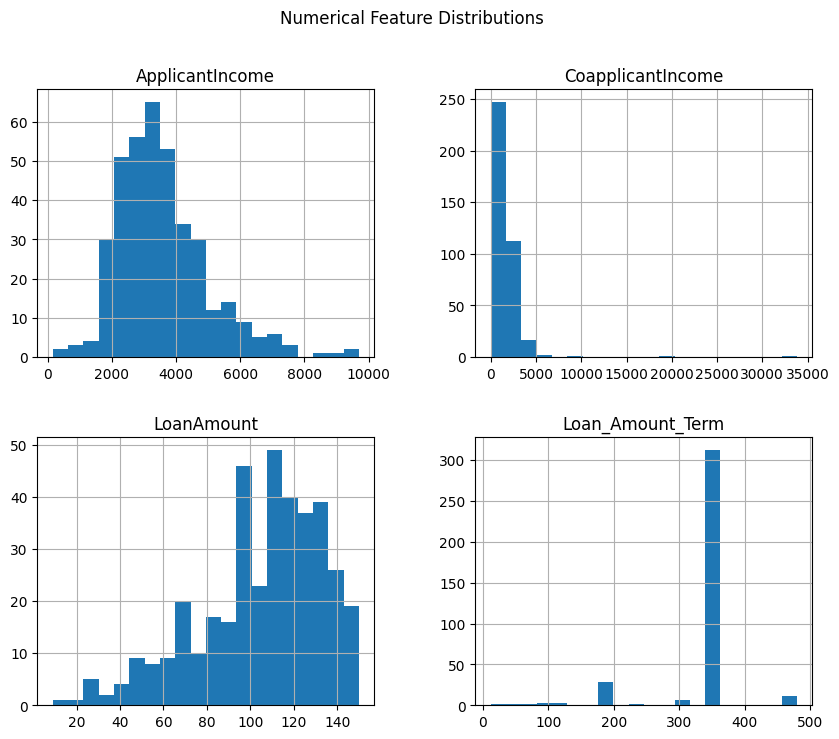

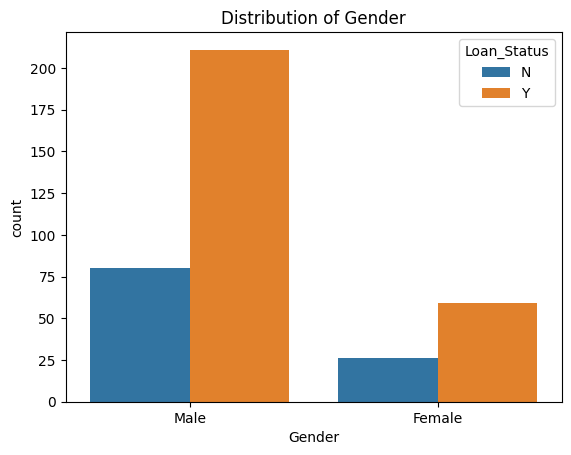

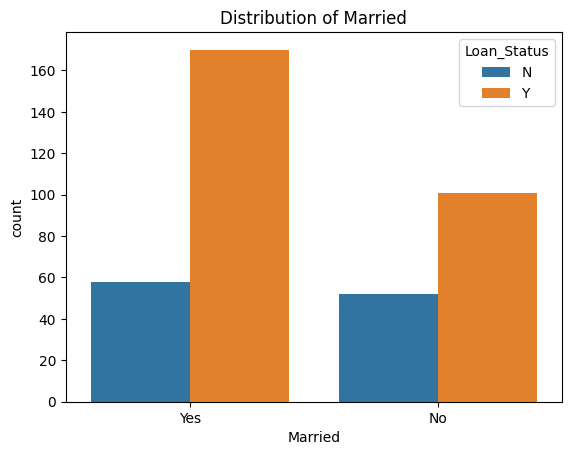

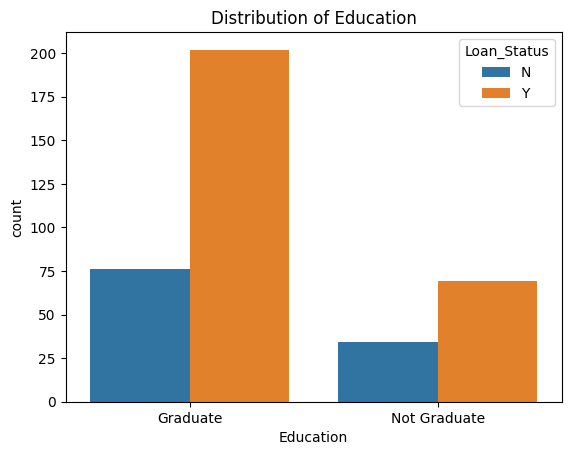

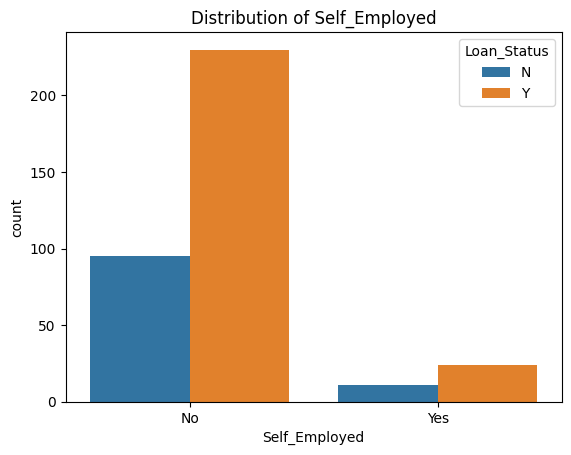

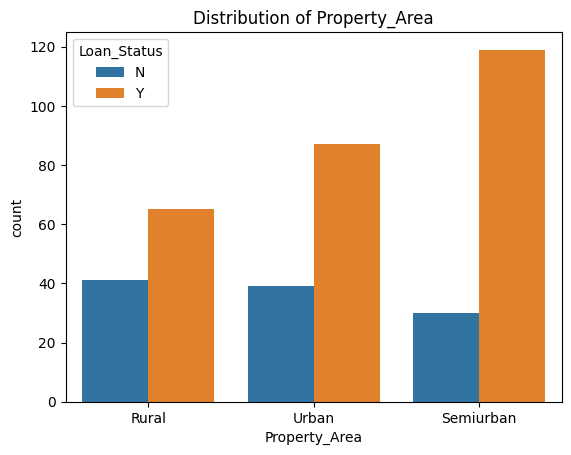


Data Types After Encoding:
 Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome      float64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
dtype: object

First Five Rows After Encoding:
    Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        1           1          0              0         0.707469   
1       1        1           0          0              1        -0.408932   
2       1        1           0          1              0        -0.703019   
3       1        0           0          0              0         1.706799   
4       1        1           0          1              0        -0.879330   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0           0.098695    0.812575          

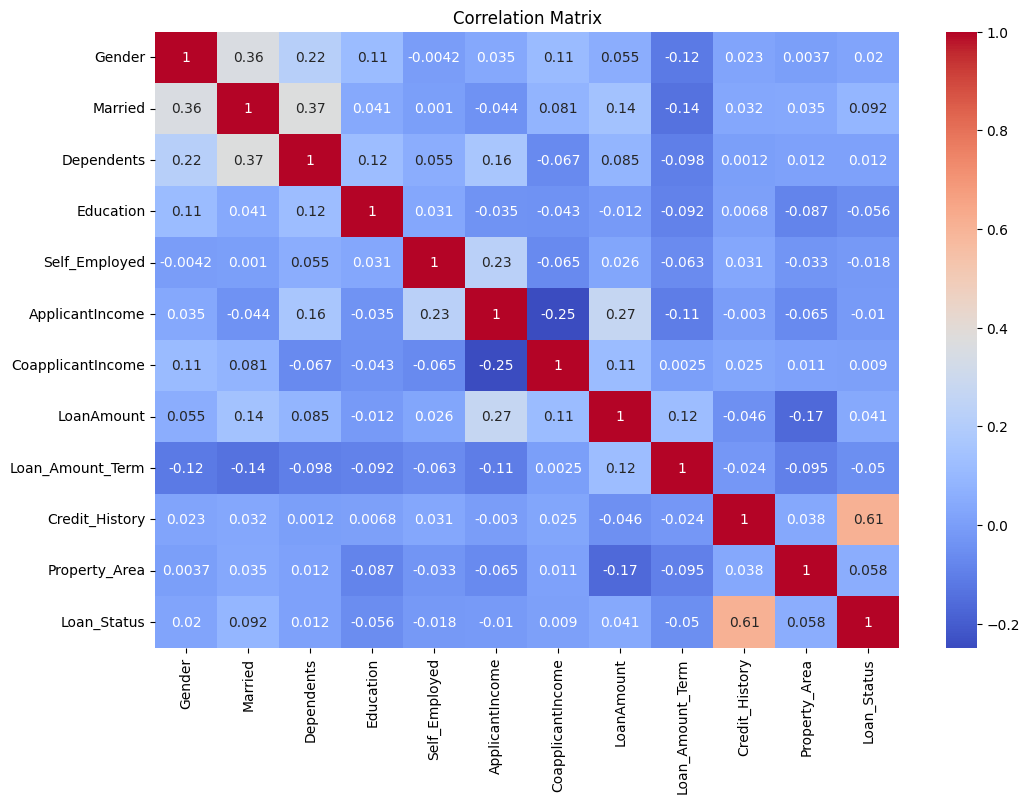


Data Types Before Training:
 Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome      float64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
dtype: object

Checking for NaN values in X before training: 0
Random Forest best parameters: {'max_depth': 5, 'n_estimators': 100}
SVM best parameters: {'C': 0.1, 'kernel': 'linear'}

Evaluating Logistic Regression Model:
Accuracy: 0.8441558441558441
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.48      0.65        23
           1       0.82      1.00      0.90        54

    accuracy                           0.84        77
   macro avg       0.91      0.74      0.77        77
weighted avg       0.87      0.84      0.82        77

Confusion Matrix:
 [[11 12]
 [ 0 54]]

Evaluatin

In [ ]:
# Run the main function
if (__name__) == '__main__':
    main()